# Notebook 3 — Modélisation

L'objectif ici est de comparer plusieurs algorithmes sur ce problème de crédit
scoring pour identifier le meilleur point de départ avant optimisation.

Je teste 5 modèles du plus simple au plus puissant : Dummy baseline, Régression
Logistique, Random Forest, XGBoost et LightGBM. Toutes les expériences sont
trackées dans MLflow pour pouvoir les comparer facilement.

## Chargement des données

Je charge le dataset produit par le notebook 2. La cible `TARGET` est séparée des
features, et `SK_ID_CURR` est retiré — c'est un identifiant, pas une feature
prédictive.

In [1]:
import sys
sys.path.insert(0, '..')
from src.visualizer import plot_metrics_comparison, create_barh
from src.modelization import evaluate_model, trouver_seuil_optimal
from src.preprocessing import build_preprocessor
from src.utils import distribution_column

import mlflow
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from tqdm.notebook import tqdm


mlflow.set_tracking_uri("sqlite:///../mlflow.db")
mlflow.set_experiment("credit-scoring")

<Experiment: artifact_location='/home/rapha/ai-engineer/credit-scoring-mlops/mlruns', creation_time=1773648058682, experiment_id='1', last_update_time=1773648058682, lifecycle_stage='active', name='credit-scoring', tags={}, workspace='default'>

In [2]:
# Chargement des données prétraitées
df_train = pd.read_csv("../data/processed/train_processed.csv")

# Séparation features / cible
X = df_train.drop(columns=["TARGET", "SK_ID_CURR"])
y = df_train["TARGET"]

print(f"Features : {X.shape[1]} colonnes")
print(f"Échantillons : {X.shape[0]} lignes")
distribution_column(pd.DataFrame({'TARGET': y}), 'TARGET')



Features : 112 colonnes
Échantillons : 307511 lignes

📊 Distribution de la colonne 'TARGET'
----------------------------------------------------------------------------------------------------


,Effectif,Pourcentage (%)
TARGET,,
0,282686,91.93
1,24825,8.07


In [3]:
# Sous-échantillon stratifié pour accélérer les tests (10% du dataset)
# Mettre MODE_TEST = False pour l'entraînement final sur tout le dataset
MODE_TEST = False

DATASET_FILTER = "full" if not MODE_TEST else "sample_10pct"


if MODE_TEST:
    _, X_sample, _, y_sample = train_test_split(
        X, y, test_size=0.1, stratify=y, random_state=42
    )
    print(f"Mode test — échantillon : {X_sample.shape[0]} lignes")
else:
    X_sample, y_sample = X, y
    print(f"Mode complet — {X_sample.shape[0]} lignes")

Mode complet — 307511 lignes


In [4]:
# Identification des types de colonnes
num_cols = X_sample.select_dtypes(include='number').columns.tolist()
cat_cols = X_sample.select_dtypes(include='object').columns.tolist()

# Preprocesseur commun à tous les modèles (construit via src/preprocessing.py)
preprocessor = build_preprocessor(num_cols, cat_cols)

print(f'Colonnes numériques   : {len(num_cols)}')
print(f'Colonnes catégorielles : {len(cat_cols)}')

Colonnes numériques   : 99
Colonnes catégorielles : 13


## Choix des métriques de validation

Trois métriques sont utilisées pour évaluer et comparer les modèles :

- **ROC-AUC** — métrique principale de discrimination. Elle mesure la capacité du modèle à séparer les bons et mauvais clients indépendamment du seuil de décision. Au-delà de 0.82, suspicion d'overfitting (= 1er du challenge Kaggle)

- **Recall** — proportion de mauvais clients correctement détectés. Prioritaire ici car les Faux Négatifs (crédit accordé à un mauvais client) sont 10× plus coûteux que les Faux Positifs.

- **F1** — moyenne harmonique précision/recall. Utile pour comparer les modèles sur un équilibre global, sans être trompé par le déséquilibre des classes (~8% de positifs).

La **précision seule** n'est pas retenue : avec un coût asymétrique (FN × 10 vs FP × 1), on accepte volontairement de sacrifier de la précision pour maximiser le recall.

Le **coût métier** (FN × 10 + FP × 1) au seuil optimal est calculé séparément sur le jeu de validation — c'est le critère de sélection final du modèle champion.

In [5]:
# Métriques de validation croisée utilisées pour tous les modèles
scoring = {
    'roc_auc': 'roc_auc',
    'recall':  'recall',
    'f1':      'f1',
}

# Split train/validation — le coût métier est calculé sur X_val (données non vues)
X_train, X_val, y_train, y_val = train_test_split(
    X_sample, y_sample, test_size=0.2, stratify=y_sample, random_state=42
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"Train : {X_train.shape[0]} lignes | Validation : {X_val.shape[0]} lignes")

Train : 246008 lignes | Validation : 61503 lignes


## Définition et entraînement des modèles

Chaque modèle est intégré dans un `Pipeline` sklearn qui enchaîne :
- le preprocessing (imputation, encodage),
- puis le modèle de classification.

Cette approche permet d’éviter toute fuite de données entre les folds lors de la validation croisée.

Le dataset est déséquilibré (environ 8 % de mauvais clients). Pour corriger ce déséquilibre, le paramètre `class_weight='balanced'` est utilisé sur tous les modèles compatibles.

### Pourquoi ne pas utiliser SMOTE ni l’undersampling ?

Pour gérer le déséquilibre des classes, j’ai choisi d’utiliser `class_weight='balanced'` plutôt que des techniques de rééchantillonnage.

Ce choix repose sur plusieurs raisons :

- **SMOTE** génère des observations synthétiques à partir des voisins proches. Avec 111 variables, ces données artificielles peuvent être moins fiables et introduire du bruit.
- **L’undersampling** consiste à supprimer une partie des données majoritaires. Sur un dataset de 307k lignes, cela entraînerait la perte d’environ 230k observations, ce qui réduit l’information disponible.
- **LightGBM** et **XGBoost** gèrent déjà efficacement le déséquilibre des classes via `class_weight` ou `scale_pos_weight`. Le rééchantillonnage apporte donc peu de bénéfice supplémentaire.
- Dans ce projet, le principal levier pour améliorer la performance (problème à coût asymétrique) est l’optimisation du seuil de décision, réalisée dans le notebook `4_optimization.ipynb`, plutôt que la modification de la distribution des classes.

In [6]:
def evaluate_model_credit(name, pipeline, params):
    """Wrapper métier autour de evaluate_model.

    Ouvre le run MLflow, délègue l'entraînement et le logging générique à
    evaluate_model, puis ajoute les métriques spécifiques au projet :
    coût métier et seuil de décision optimal.
    """
    with mlflow.start_run(run_name=name):
        result = evaluate_model(
            name, pipeline, params,
            X_train, y_train, X_val,
            cv, scoring,
            dataset_source="../data/processed/train_processed.csv",
        )

        # Métriques métier
        seuil_opt, cout_opt = trouver_seuil_optimal(y_val, result['y_proba_val'])
        mlflow.log_metric('cout_metier',   cout_opt)
        mlflow.log_metric('seuil_optimal', seuil_opt)
        mlflow.set_tag("dataset", DATASET_FILTER)

        summary = result['summary']
        auc    = round(summary['roc_auc']['test_mean'], 4)
        recall = round(summary['recall']['test_mean'],  4)
        f1     = round(summary['f1']['test_mean'],      4)
        print(f"[{name}] AUC={auc:.4f} | Recall={recall:.4f} | F1={f1:.4f} | Coût métier (seuil={seuil_opt})={cout_opt}")

In [7]:
# Définition des modèles à comparer : (nom_run, pipeline, params_mlflow)
modeles = [
    (
        'dummy_baseline',
        Pipeline([('preprocessor', preprocessor), ('clf', DummyClassifier(
            strategy='most_frequent', random_state=42
        ))]),
        {'model': 'DummyClassifier', 'strategy': 'most_frequent'},
    ),
    (
        'logistic_regression',
        Pipeline([('preprocessor', preprocessor), ('clf', LogisticRegression(
            class_weight='balanced', max_iter=1000, random_state=42
        ))]),
        {'model': 'LogisticRegression', 'class_weight': 'balanced'},
    ),
    (
        'random_forest',
        Pipeline([('preprocessor', preprocessor), ('clf', RandomForestClassifier(
            n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1
        ))]),
        {'model': 'RandomForest', 'n_estimators': 100, 'class_weight': 'balanced'},
    ),
    (
        'xgboost',
        Pipeline([('preprocessor', preprocessor), ('clf', XGBClassifier(
            n_estimators=200, scale_pos_weight=9, random_state=42,
            n_jobs=-1, eval_metric='logloss', verbosity=0
        ))]),
        {'model': 'XGBoost', 'n_estimators': 200, 'scale_pos_weight': 9},
    ),
    (
        'lightgbm',
        Pipeline([('preprocessor', preprocessor), ('clf', LGBMClassifier(
            n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1
        ))]),
        {'model': 'LightGBM', 'n_estimators': 200, 'class_weight': 'balanced'},
    ),
]

In [8]:
for nom, pipeline, params in tqdm(modeles, desc="Évaluation des modèles"):
    evaluate_model_credit(nom, pipeline, params)

Évaluation des modèles:   0%|          | 0/5 [00:00<?, ?it/s]


[dummy_baseline] Entraînement en cours...



/home/rapha/ai-engineer/credit-scoring-mlops/.venv/lib/python3.13/site-packages/mlflow/data/dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(
/home/rapha/ai-engineer/credit-scoring-mlops/.venv/lib/python3.13/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See 

[dummy_baseline] AUC=0.5000 | Recall=0.0000 | F1=0.0000 | Coût métier (seuil=0.0)=56538

[logistic_regression] Entraînement en cours...



/home/rapha/ai-engineer/credit-scoring-mlops/.venv/lib/python3.13/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/03/20 10:55:36 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, wh

...

[random_forest] AUC=0.7344 | Recall=0.0014 | F1=0.0028 | Coût métier (seuil=0.1)=33437

[xgboost] Entraînement en cours...



/home/rapha/ai-engineer/credit-scoring-mlops/.venv/lib/python3.13/site-packages/mlflow/data/dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(
/home/rapha/ai-engineer/credit-scoring-mlops/.venv/lib/python3.13/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See 

[xgboost] AUC=0.7477 | Recall=0.4762 | F1=0.2974 | Coût métier (seuil=0.3858)=32502

[lightgbm] Entraînement en cours...



/home/rapha/ai-engineer/credit-scoring-mlops/.venv/lib/python3.13/site-packages/mlflow/data/dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(
/home/rapha/ai-engineer/credit-scoring-mlops/.venv/lib/python3.13/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See 

[lightgbm] AUC=0.7709 | Recall=0.6604 | F1=0.2875 | Coût métier (seuil=0.5514)=30779


## Comparaison des résultats

Je récupère les métriques de tous les runs depuis MLflow pour les comparer.
Le critère de sélection principal est le **coût métier** (FN × 10 + FP × 1),
pas l'AUC seule — accorder un crédit à quelqu'un qui ne remboursera pas coûte
10× plus cher que refuser un bon client.

In [9]:

# Récupération des runs MLflow de cette expérience
df_runs = mlflow.search_runs(experiment_names=["credit-scoring"])
df_runs = (
    df_runs[df_runs["tags.dataset"] == DATASET_FILTER]
    .sort_values("start_time", ascending=False)
    .head(5)
)

# Tableau récapitulatif
cols = {
    "tags.mlflow.runName":        "Modèle",
    "metrics.roc_auc_test_mean":  "ROC-AUC test",
    "metrics.roc_auc_train_mean": "ROC-AUC train",
    "metrics.recall_test_mean":   "Recall",
    "metrics.f1_test_mean":       "F1",
    "metrics.cout_metier":        "Coût métier",
    "metrics.seuil_optimal":      "Seuil optimal",
    "metrics.fit_time_final":     "Fit (s)",
    "metrics.predict_time_val":   "Predict (s)",
}
df_summary = (
    df_runs[list(cols.keys())]
    .rename(columns=cols)
    .set_index("Modèle")
    .sort_values("ROC-AUC test", ascending=False)
    .round(4)
)
df_summary.insert(2, "Gap", (df_summary["ROC-AUC train"] - df_summary["ROC-AUC test"]).round(4))
df_summary


,ROC-AUC test,ROC-AUC train,Gap,Recall,F1,Coût métier,Seuil optimal,Fit (s),Predict (s)
Modèle,,,,,,,,,
lightgbm,0.7709,0.8540,0.0831,0.6604,0.2875,30779.0,0.5514,7.932,0.316
logistic_regression,0.7585,0.7611,0.0026,0.6841,0.2673,31833.0,0.5300,9.467,0.411
xgboost,0.7477,0.9440,0.1963,0.4762,0.2974,32502.0,0.3858,11.152,0.322
random_forest,0.7344,1.0000,0.2656,0.0014,0.0028,33437.0,0.1000,24.331,0.658
dummy_baseline,0.5000,0.5000,0.0000,0.0000,0.0000,56538.0,0.0000,3.749,0.261


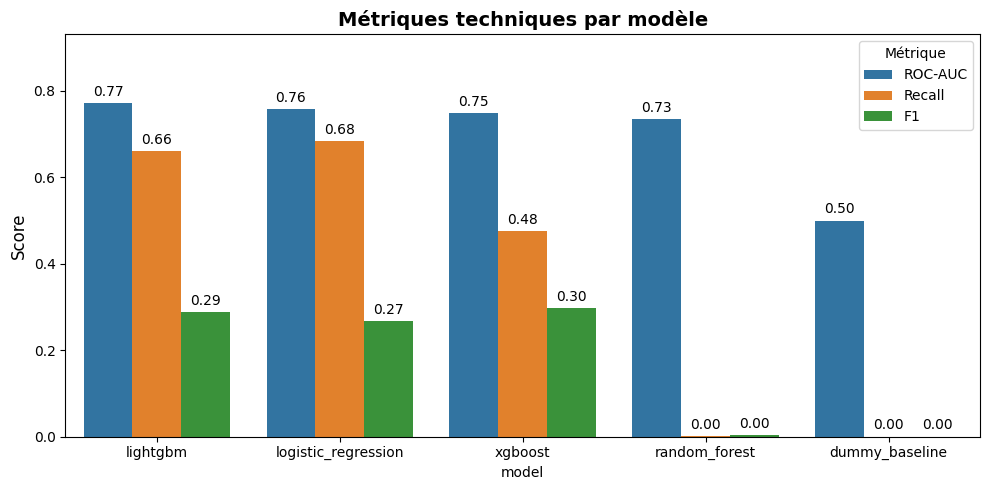

In [10]:
# Comparaison des métriques techniques (ROC-AUC, Recall, F1) par modèle
fig, ax = plt.subplots(figsize=(10, 5))

plot_metrics_comparison(
    df_summary[["ROC-AUC test", "Recall", "F1"]],
    ax,
    metric_cols={"ROC-AUC test": "ROC-AUC", "Recall": "Recall", "F1": "F1"},
    title="Métriques techniques par modèle",
    ylabel="Score",
)

plt.tight_layout()
plt.show()

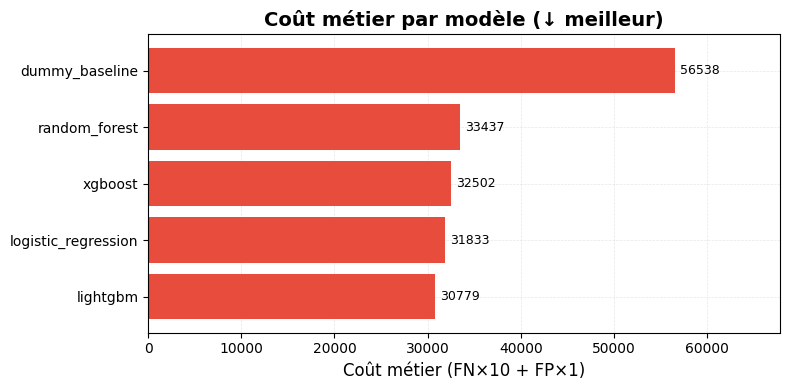

In [11]:
# Coût métier par modèle — critère de sélection principal (↓ meilleur)
fig, ax = plt.subplots(figsize=(8, 4))

df_cout = df_summary[["Coût métier"]].reset_index()
df_cout.columns = ["modele", "cout"]

create_barh(
    df_cout, ax,
    x="cout", y="modele",
    title="Coût métier par modèle (↓ meilleur)",
    xlabel="Coût métier (FN×10 + FP×1)",
    color="#e74c3c",
    fmt="{:.0f}",
)

plt.tight_layout()
plt.show()

## Choix du modèle final : LightGBM

D'après les résultats obtenus, **LightGBM est retenu comme modèle final**.

| Modèle | ROC-AUC | Recall | Coût métier |
|---|---|---|---|
| **LightGBM** | **0.7709** | 0.6604 | **30 779** |
| Logistic Regression | 0.7585 | 0.6841 | 31 840 |
| XGBoost | 0.7477 | 0.4762 | 32 567 |
| Random Forest | 0.7375 | 0.0016 | 33 274 |

### Justification du choix

Le choix du modèle repose principalement sur le **coût métier**, qui est l'indicateur prioritaire dans ce projet.

- **Meilleur ROC-AUC (0.7709)**  
  LightGBM offre la meilleure capacité de discrimination entre bons et mauvais clients parmi les modèles testés.

- **Coût métier le plus faible (30 779)**  
  Cet indicateur pénalise davantage les faux négatifs (FN × 10) que les faux positifs (FP × 1), car accorder un crédit à un client à risque est plus coûteux que refuser un client solvable.  
  LightGBM minimise ce coût global et constitue donc le meilleur compromis opérationnel.

- **Recall satisfaisant (0.6604)**  
  Bien que légèrement inférieur à celui de la régression logistique, ce recall reste correct et s'accompagne d'un meilleur coût métier, ce qui justifie le choix final.

### Analyse des modèles non retenus

- **Random Forest**  
  Le recall quasi-nul (0.0016) s'explique par la **mauvaise calibration des probabilités** des forêts aléatoires. RF tend à produire des probabilités concentrées proches de 0 ou de 1, non uniformément distribuées sur [0, 1]. Résultat : même au seuil le plus bas testé (0.1), presque aucun client n'atteint ce seuil — la classe 1 n'est quasiment jamais prédite. Une calibration de probabilités (`CalibratedClassifierCV`) améliorerait ce comportement, mais ce modèle reste dominé par LightGBM sur toutes les métriques — il n'est donc pas retenu.

- **XGBoost**  
  L'écart important entre le score d'entraînement (AUC = 0.944) et le score de test (AUC = 0.748) suggère un surapprentissage avec les hyperparamètres par défaut. Une régularisation supplémentaire serait nécessaire pour améliorer sa capacité de généralisation.

### Prochaine étape

Le modèle LightGBM est enregistré dans le **Model Registry MLflow**, puis optimisé dans le notebook 4 :
- optimisation des hyperparamètres avec Optuna,
- ajustement du seuil de décision pour réduire le coût métier.

## Enregistrement dans le Model Registry

Le modèle **LightGBM** est enregistré dans le **MLflow Model Registry** sous le nom `credit-scoring-model`.

Un alias `staging` lui est attribué : le modèle est fonctionnel et validé techniquement, mais il n’a pas encore été optimisé (réglage des hyperparamètres et du seuil de décision à venir).

In [12]:
# Enregistrement du meilleur modèle (LightGBM) dans le Model Registry
runs = mlflow.search_runs(
    experiment_names=["credit-scoring"],
    filter_string="tags.mlflow.runName = 'lightgbm'",
    order_by=["start_time DESC"],
    max_results=1,
	output_format="pandas",
)
best_run_id = runs.iloc[0]["run_id"]
registered = mlflow.register_model(f"runs:/{best_run_id}/model", "credit-scoring-model")
print(f"Modèle LightGBM enregistré dans le registry (run_id={best_run_id})")

# Alias 'staging' — modèle candidat validé techniquement, pas encore optimisé
from mlflow import MlflowClient
MlflowClient().set_registered_model_alias(
    name="credit-scoring-model",
    alias="staging",
    version=registered.version,
)
print(f"Version {registered.version} — alias 'staging' assigné")

Registered model 'credit-scoring-model' already exists. Creating a new version of this model...
2026/03/20 11:01:56 WARNING mlflow.tracking._model_registry.fluent: Run with id 321780c332b6447e9998cc308ace0217 has no artifacts at artifact path 'model', registering model based on models:/m-368ea9b0223146aaa18d0ea0f2045400 instead


Modèle LightGBM enregistré dans le registry (run_id=321780c332b6447e9998cc308ace0217)
Version 10 — alias 'staging' assigné


Created version '10' of model 'credit-scoring-model'.
